In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Read the dirty dataset
data = pd.read_csv('data/cost_revenue_dirty.csv')
print("Initial Structural Shape:", data.shape)

# 2. Clean text formatting characters using nested loops
chars_to_remove = [',', '$']
columns_to_clean = ['USD_Production_Budget', 'USD_Worldwide_Gross', 'USD_Domestic_Gross']

for col in columns_to_clean:
    for char in chars_to_remove:
        data[col] = data[col].astype(str).str.replace(char, "")
    data[col] = pd.to_numeric(data[col])

# 3. Convert dates to pandas datetime objects
data.Release_Date = pd.to_datetime(data.Release_Date)
data.info()

Initial Structural Shape: (5391, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Rank                   5391 non-null   int64         
 1   Release_Date           5391 non-null   datetime64[ns]
 2   Movie_Title            5391 non-null   object        
 3   USD_Production_Budget  5391 non-null   int64         
 4   USD_Worldwide_Gross    5391 non-null   int64         
 5   USD_Domestic_Gross     5391 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 252.8+ KB


In [6]:
# Isolate future releases
scrape_date = pd.Timestamp('2018-05-01')
future_releases = data[data.Release_Date >= scrape_date]

# Create data_clean by dropping future releases
data_clean = data.drop(future_releases.index)
print("Clean Dataframe Dimensions:", data_clean.shape)

Clean Dataframe Dimensions: (5384, 6)


In [7]:
# 1. Create a year array index tracking sequence
dt_index = pd.DatetimeIndex(data_clean.Release_Date)
years = dt_index.year

# 2. Apply floor division calculation trick to isolate decades
decades = (years // 10) * 10
data_clean['Decade'] = decades

# 3. Separate old cinema from the modern blockbuster era
old_films = data_clean[data_clean.Decade < 1970]
new_films = data_clean[data_clean.Decade >= 1970]

print(f"Number of historical classic films (<1970): {len(old_films)}")
print(f"Number of modern era blockbuster films (>=1970): {len(new_films)}")

Number of historical classic films (<1970): 153
Number of modern era blockbuster films (>=1970): 5231


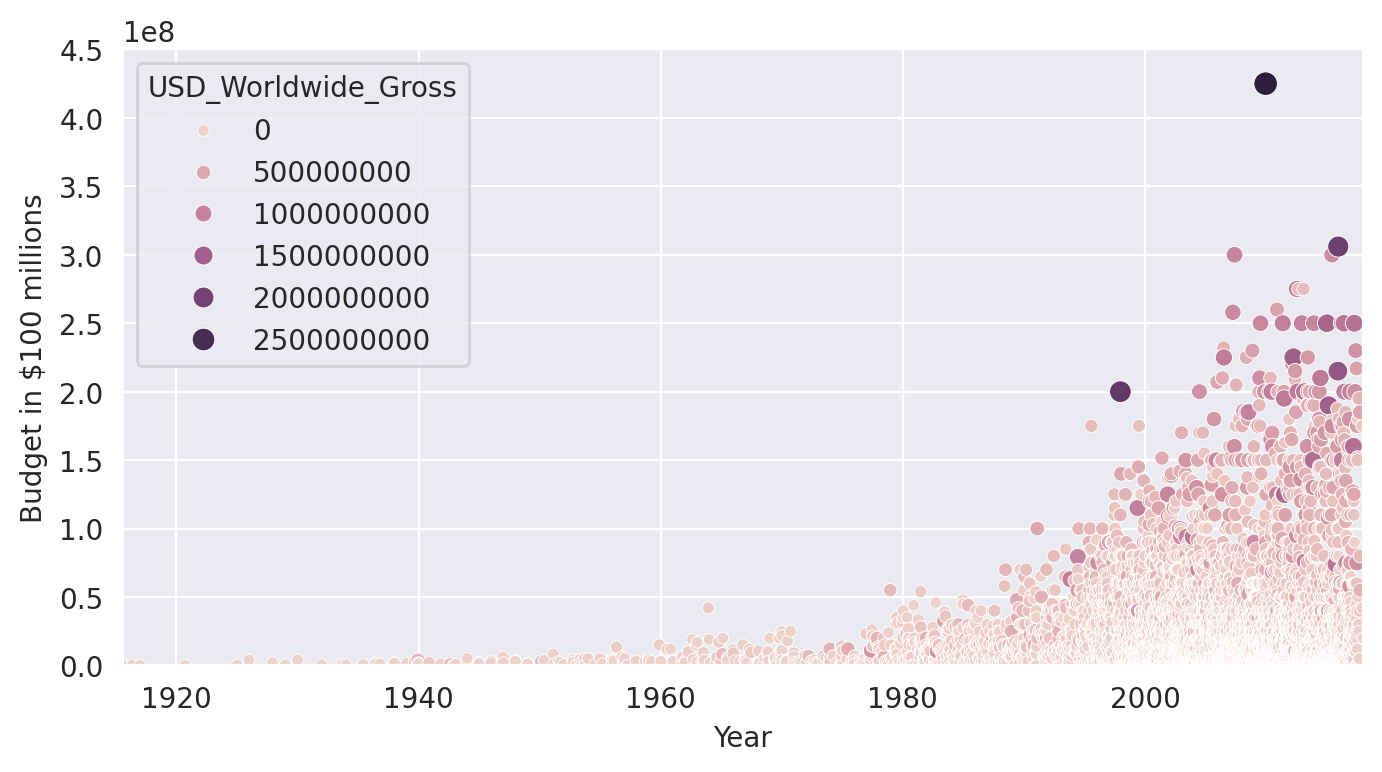

In [8]:
plt.figure(figsize=(8,4), dpi=200)

# Apply a clean darkgrid theme bracket constraint
with sns.axes_style("darkgrid"):
    ax = sns.scatterplot(
        data=data_clean,
        x='Release_Date',
        y='USD_Production_Budget',
        hue='USD_Worldwide_Gross', # Maps color gradients to box office revenue
        size='USD_Worldwide_Gross'  # Maps bubble point sizing to box office revenue
    )

    ax.set(
        ylim=(0, 450000000),
        xlim=(data_clean.Release_Date.min(), data_clean.Release_Date.max()),
        xlabel='Year',
        ylabel='Budget in $100 millions'
    )
plt.show()

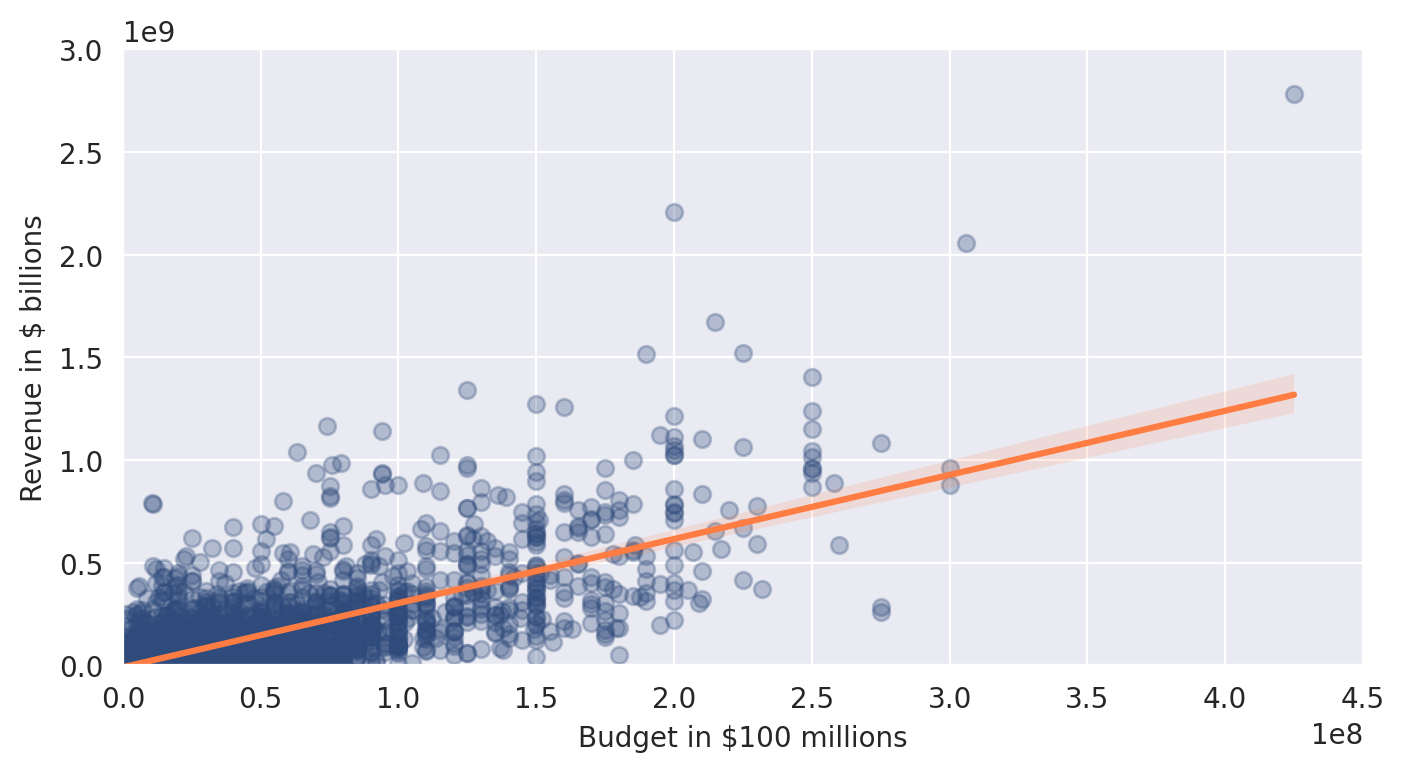

In [9]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('darkgrid'):
  ax = sns.regplot(
      data=new_films,
      x='USD_Production_Budget',
      y='USD_Worldwide_Gross',
      color='#2f4b7c',          # Dark blue points
      scatter_kws = {'alpha': 0.3},
      line_kws = {'color': '#ff7c43'} # Bright orange regression line
  )

  ax.set(
      ylim=(0, 3000000000),
      xlim=(0, 450000000),
      ylabel='Revenue in $ billions',
      xlabel='Budget in $100 millions'
  )
plt.show()

In [10]:
# 1. Format feature matrices (X) and target vectors (y) as DataFrames
X = pd.DataFrame(new_films, columns=['USD_Production_Budget'])
y = pd.DataFrame(new_films, columns=['USD_Worldwide_Gross'])

# 2. Initialize and fit the Machine Learning Regression Model
regression = LinearRegression()
regression.fit(X, y)

# 3. Calculate metrics
r_squared = regression.score(X, y)
slope = regression.coef_[0][0]
intercept = regression.intercept_[0]

print(f"Model R-Squared (Goodness of Fit): {r_squared:.3f}")
print(f"Slope Coefficient (Theta 1): {slope:.2f}")
print(f"Y-Intercept Constant (Theta 0): ${intercept:,.2f}")

Model R-Squared (Goodness of Fit): 0.558
Slope Coefficient (Theta 1): 3.12
Y-Intercept Constant (Theta 0): $-8,650,768.01


In [11]:
budget_query = [[350000000]]
predicted_revenue = regression.predict(budget_query)[0][0]

print(f"The model estimates a $350M budget film will gross: ${predicted_revenue:,.2f}")

The model estimates a $350M budget film will gross: $1,084,257,803.06


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


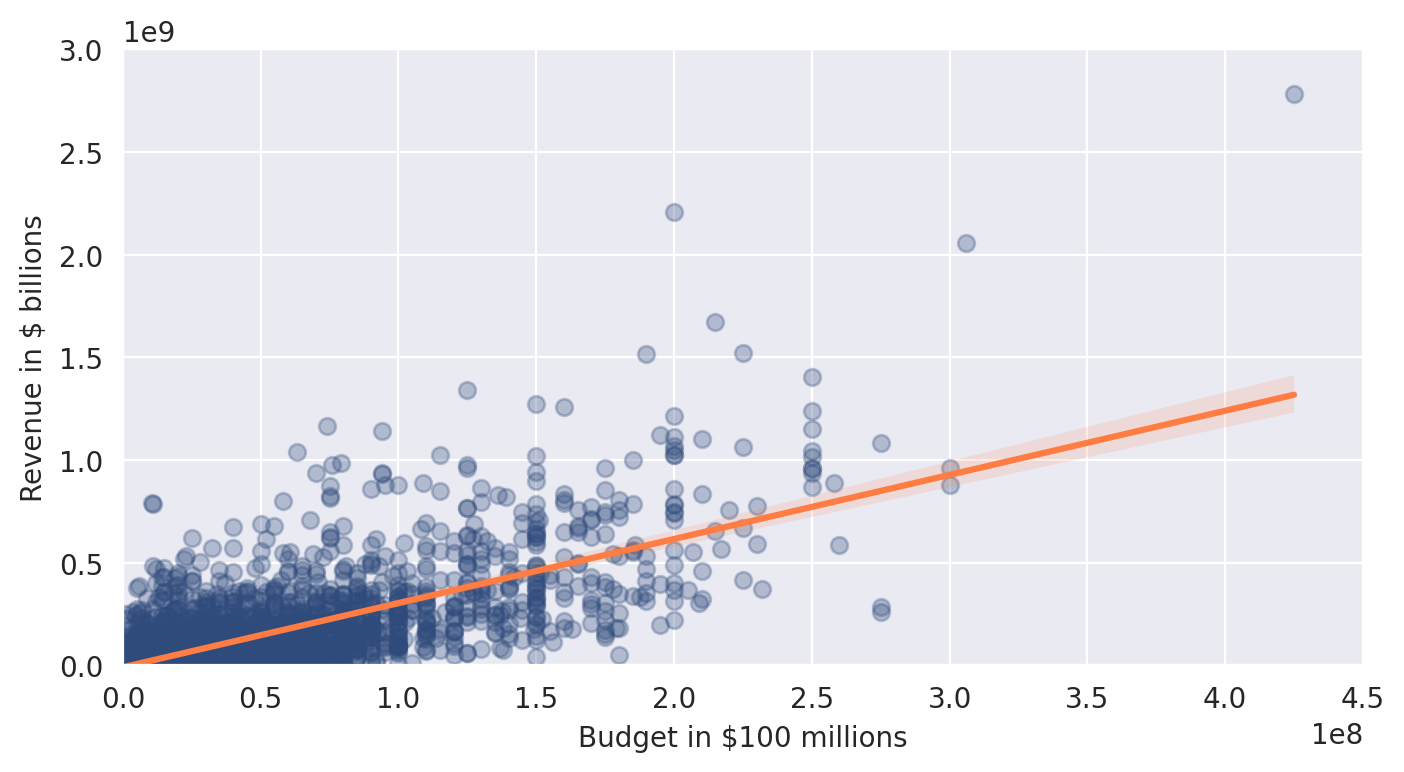

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize a clean high-resolution canvas room
plt.figure(figsize=(8,4), dpi=200)

# 2. Superimpose the linear regression line over the post-1970 movies data
with sns.axes_style('darkgrid'):
  ax = sns.regplot(
      data=new_films,
      x='USD_Production_Budget',
      y='USD_Worldwide_Gross',
      color='#2f4b7c',                # Deep slate blue scatter dots
      scatter_kws = {'alpha': 0.3},
      line_kws = {'color': '#ff7c43'} # Bright orange regression trend line
  )

  # 3. Fine-tune axes constraints and label limits
  ax.set(
      ylim=(0, 3000000000),
      xlim=(0, 450000000),
      ylabel='Revenue in $ billions',
      xlabel='Budget in $100 millions'
  )

plt.show()